# Dataset selection v2: which orbits/epochs make good TRN-OD test data?

**Exploratory, early-stage** -- not wired into the demo pipeline. Will eventually replace
`data_set_selection.ipynb`'s selection logic, but doesn't yet: that notebook and
`dataset_manifest.csv` are untouched, so the existing demo keeps working unchanged while this one
develops independently.

The near-term goal here isn't picking one image -- it's building intuition about which *orbits*
(and which *time periods*) are good candidates for a TRN-based orbit-determination test dataset,
where consecutive images need to be maneuver-free in between (see `docs/data-sources.md`'s "LRO
maneuver detection" section and `src/trntest/maneuver_detection.py`).

The actual selection logic lives in `src/trntest/dataset_selection.py` (orbit-level statistics,
candidate enumeration, the greedy diversity-selection algorithm) and `src/trntest/plotting.py`
(both plots below) -- this notebook is just that pipeline's tunable parameters plus the calls
themselves, so it stays a scannable narrative rather than the place the actual logic lives.

## The illuminated node

Every LRO orbit has an ascending node and a descending node (where the ground track crosses the
lunar equator going north/south), ~180 deg apart in longitude. Because they're on opposite sides
of the Moon, only one of the two is typically sunlit -- we call that one **the illuminated node**,
picked as whichever of the pair has the higher sun elevation (an arbitrary but reasonable
tie-break; the rare case where neither/both are lit just means LRO is near the terminator on both
passes, not a time of particular interest for this dataset anyway).

For each orbit, `dataset_selection.find_orbits` collects:

1. Solar hour angle at the sub-satellite point under the illuminated node (degrees: -90 =
   sunrise, 0 = local noon, +90 = sunset).
2. Longitude of the illuminated node.
3. Number of "acceptable" WAC EDRs in the orbit -- typical nadir mapping-mode acquisitions
   (low emission angle) with sun elevation above a tunable minimum.
4. Whether the orbit contains a propulsive maneuver.

The period of interest here is all of 2019.

In [1]:
from datetime import datetime

from trntest import TrnTestDataSet, dataset_selection, plotting
from trntest.config import load_config

config = load_config()

PERIOD_START = datetime(2019, 1, 1)
PERIOD_END = datetime(2020, 1, 1)  # exclusive -- orbits must complete strictly before this

MIN_SUN_ELEVATION_DEG = 15.0  # statistic (3)'s "acceptable" sun-elevation floor
MAX_EMISSION_ANGLE_DEG = 15.0  # statistic (3)'s nadir/"typical mapping mode" cutoff
DATASET_LENGTH_ORBITS = 24  # ~2 days
MIN_EDR_COUNT_PER_ORBIT = 3  # an orbit needs at least this many acceptable EDRs to count as acceptable
MIN_CENTER_LONGITUDE_SEPARATION_DEG = 12.0  # how far apart selected datasets must be in center longitude
N_DATASETS = 20  # how many datasets to select

## Find every orbit and its illuminated-node statistics (1) and (2)

Furnishes a full year of SPK/CK coverage, so it's the slow one on a cold cache (several minutes --
one-time cost, cached afterward per `docs/caching.md`).

In [2]:
orbits_df = dataset_selection.find_orbits(PERIOD_START, PERIOD_END, config)
orbits_df.head()

4485 complete orbits in 2019-01-01..2020-01-01


,asc_et,next_asc_et,illum_et,illum_lon_deg,illum_is_ascending,illum_sun_elev_deg,hour_angle_deg,illum_utc
0,5.995749e+08,5.995819e+08,5.995749e+08,-129.396798,True,76.404782,-13.588758,2019-01-01 00:33:54.860000+00:00
1,5.995819e+08,5.995890e+08,5.995819e+08,-130.458090,True,76.334303,-13.659333,2019-01-01 02:31:06.413000+00:00
2,5.995890e+08,5.995960e+08,5.995890e+08,-131.521008,True,76.262231,-13.731498,2019-01-01 04:28:17.949000+00:00
3,5.995960e+08,5.996030e+08,5.995960e+08,-132.585149,True,76.188972,-13.804850,2019-01-01 06:25:29.484000+00:00
4,5.996030e+08,5.996101e+08,5.996030e+08,-133.649846,True,76.115198,-13.878716,2019-01-01 08:22:41.050000+00:00


## Maneuver flag (4)

In [3]:
orbits_df = dataset_selection.add_maneuver_flags(orbits_df, PERIOD_START, PERIOD_END, config)

20 maneuver candidates over the whole period, 20 orbits flagged


## Acceptable EDR count per orbit (3)

In [4]:
orbits_df = dataset_selection.add_acceptable_edr_counts(
    orbits_df, PERIOD_START, PERIOD_END, config, MIN_SUN_ELEVATION_DEG, MAX_EMISSION_ANGLE_DEG
)
orbits_df["acceptable_edr_count"].describe()

53324 WAC EDRs in the period, 18995 acceptable (sun_elev > 15.0 deg, emission < 15.0 deg)


count    4485.000000
mean        4.234114
std         3.112813
min         0.000000
25%         1.000000
50%         4.000000
75%         7.000000
max        10.000000
Name: acceptable_edr_count, dtype: float64

## Sun elevation vs. acceptable EDR count

How much sun elevation at the illuminated node actually buys you, in terms of acceptable-EDR
yield.

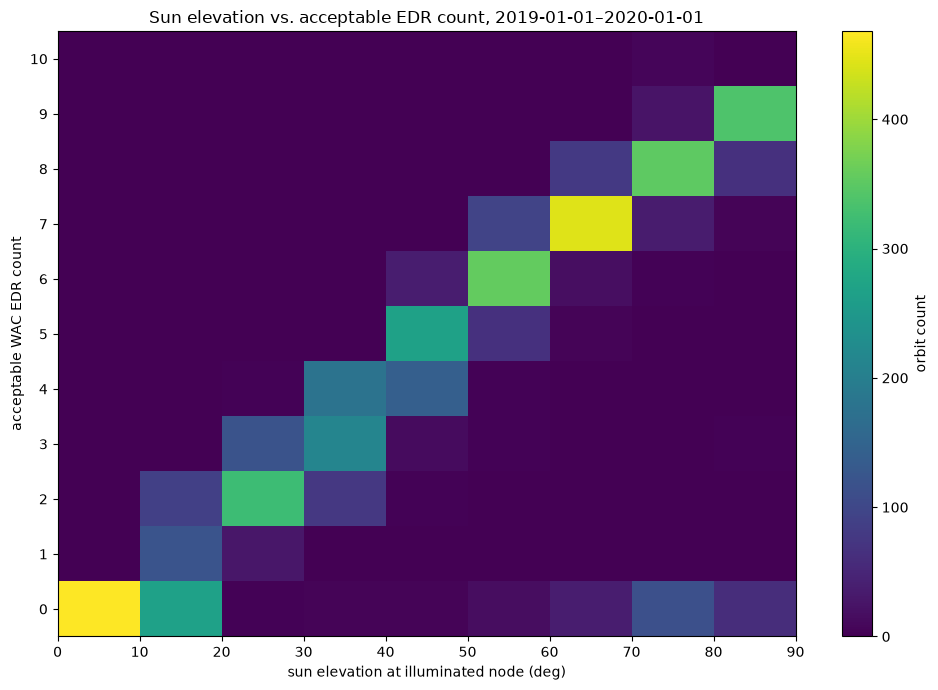

In [5]:
plotting.plot_sun_elevation_vs_edr_count(orbits_df, PERIOD_START, PERIOD_END)

## Picking multiple datasets

A **dataset** is `DATASET_LENGTH_ORBITS` consecutive orbits. It's **acceptable** if every orbit in
it is acceptable (no maneuver, and at least `MIN_EDR_COUNT_PER_ORBIT` acceptable EDRs) and it
contains no illuminated-node flip -- the no-flip rule is what makes "center" statistics (the
circular mean of the first and last orbit's value) actually behave like an average of nearby
values, rather than splitting across two ~180-degree-apart node longitudes.

Among acceptable datasets, we want to pick exactly `N_DATASETS`, each at least
`MIN_CENTER_LONGITUDE_SEPARATION_DEG` apart in center longitude from every other one chosen (and
not sharing any orbits with one already chosen), and jointly as diverse as possible in center
solar hour angle. "Diverse" is the standard greedy farthest-point/max-min criterion: each new pick
maximizes its own minimum hour-angle distance to every dataset already chosen. The very first pick
has nothing to be far from yet, so it's seeded separately: the single most robust acceptable
dataset (highest minimum per-orbit EDR count across the window). Raises rather than silently
returning fewer than `N_DATASETS` if the exclusion constraints exhaust the candidate pool first.

In [6]:
candidates_df = dataset_selection.enumerate_candidate_datasets(
    orbits_df, DATASET_LENGTH_ORBITS, MIN_EDR_COUNT_PER_ORBIT
)

2857 / 4485 individually acceptable orbits
2211 acceptable candidate datasets out of 4462 possible 24-orbit windows


In [7]:
selected_datasets = dataset_selection.select_diverse_datasets(
    candidates_df, MIN_CENTER_LONGITUDE_SEPARATION_DEG, N_DATASETS
)
selected_datasets[["start_utc", "end_utc", "center_lon_deg", "center_hour_angle_deg", "min_edr_count"]]

,start_utc,end_utc,center_lon_deg,center_hour_angle_deg,min_edr_count
0,2019-06-01 22:46:17.472000+00:00,2019-06-03 19:35:05.847000+00:00,-172.609664,5.690075,9
1,2019-08-01 12:05:32.671000+00:00,2019-08-03 09:00:39.934000+00:00,106.115950,-55.428815,3
2,2019-04-07 10:48:00.920000+00:00,2019-04-09 07:39:52.924000+00:00,-158.263108,62.698217,3
3,2019-01-10 20:51:40.568000+00:00,2019-01-12 17:47:07.746000+00:00,87.966667,-24.875087,7
4,2019-10-27 13:42:02.387000+00:00,2019-10-29 10:39:57.570000+00:00,-146.118971,34.616638,3
5,2019-07-17 14:46:37.870000+00:00,2019-07-19 11:40:46.426000+00:00,-56.578545,-40.164140,6
6,2019-06-17 10:57:11.152000+00:00,2019-06-19 07:46:03.591000+00:00,-17.412156,-9.631057,7
7,2019-11-09 16:28:51.711000+00:00,2019-11-11 13:27:46.675000+00:00,39.665473,20.136578,6
8,2019-10-14 10:58:48.292000+00:00,2019-10-16 07:56:01.700000+00:00,26.849619,47.791223,3
9,2019-11-30 19:06:05.482000+00:00,2019-12-02 16:06:18.197000+00:00,120.662315,-1.950321,8


## The plot

One marker per orbit, colored by acceptable-EDR count; a red X for any orbit with a maneuver; an
"underline" under each selected dataset's span (black for picks 1-10, grey for 11-20). See
`plotting.plot_illuminated_node_scatter`'s docstring for the full rationale.

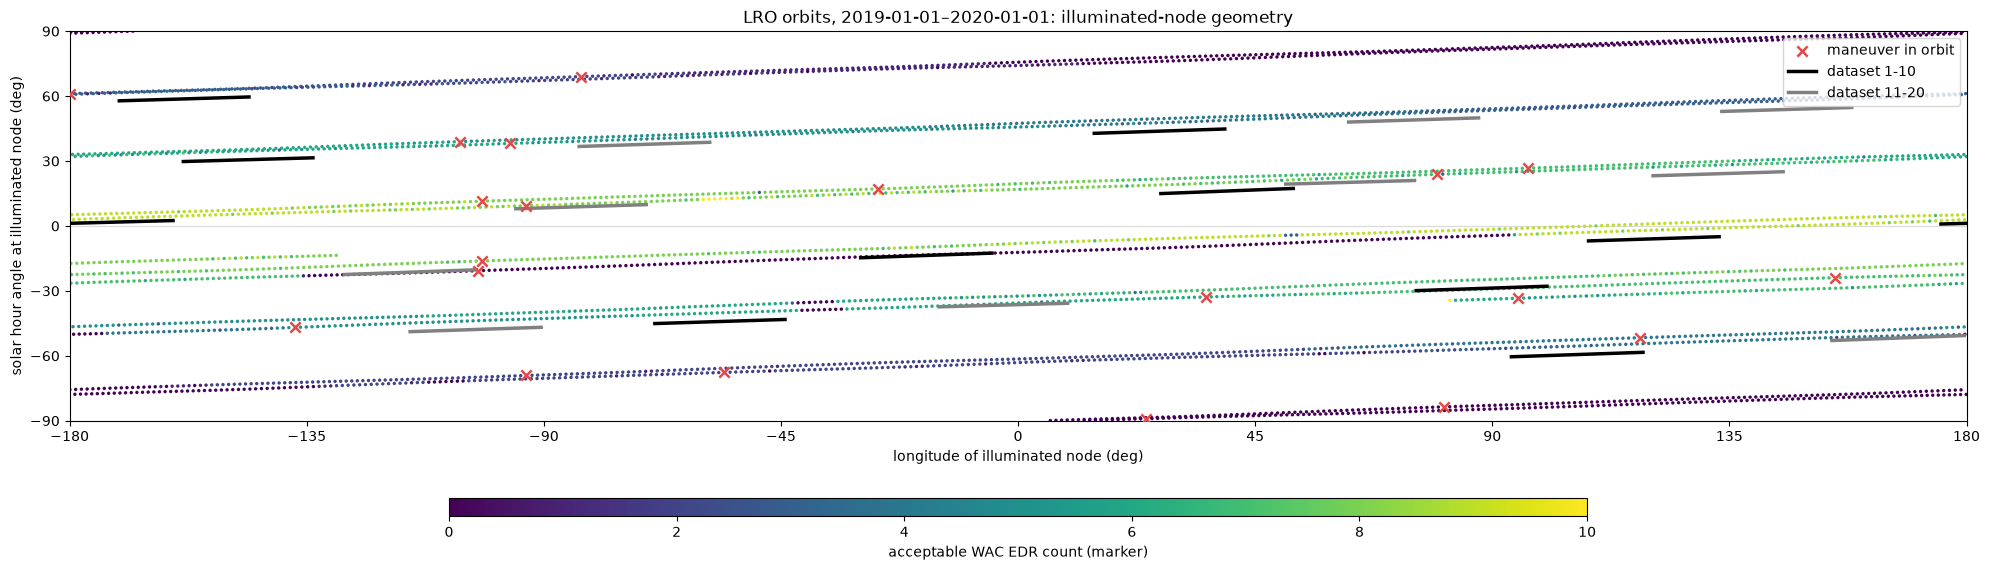

In [8]:
plotting.plot_illuminated_node_scatter(orbits_df, PERIOD_START, PERIOD_END, selected_datasets)

## Resolving one selected dataset into an image list

`selected_datasets` is orbit-level -- a start/end UTC window, no images yet. `dataset_selection.
resolve_orbit_sequence` turns exactly one selected row into a real, `TrnTestDataSet`-ready images
table (`dataset.DATASET_COLUMNS`) -- the same real per-candidate EDR-label fetch + SPICE pose
`select_dataset()` has always used, just windowed to this one selected span, and only after a
cheap catalog-metadata pre-filter narrows the raw candidate list first.

Deliberately resolves only `selected_datasets.iloc[0]`, not all `N_DATASETS` picks -- same
"iterate fast on one thing, not everything" discipline this project has followed throughout (see
`docs/history.md`); resolving the rest is a `for` loop away once this one is validated.

In [9]:
orbit_sequence = selected_datasets.iloc[0]
images = dataset_selection.resolve_orbit_sequence(orbit_sequence, config, MIN_SUN_ELEVATION_DEG, MAX_EMISSION_ANGLE_DEG)
images

,product_id,edr_volume,edr_subdir,edr_doy,edr_product,cdr_volume,cdr_subdir,cdr_doy,cdr_product,orbit_number,start_time,stop_time,start_frame,center_frame_index,n_frames_for_square_crop,sun_elevation_deg,incidence_angle_deg,center_lat_deg,center_lon_deg
0,M1314068239CE,LROLRC_0039C,ESM3,2019152,M1314068239CE,None,None,None,None,44755,2019-06-01 22:42:51.369000+00:00,2019-06-01 22:53:44.119000+00:00,335.0,373.0,76,81.445116,8.56,-6.1206,200.1609
1,M1314068896CE,LROLRC_0039C,ESM3,2019152,M1314068896CE,None,None,None,None,44755,2019-06-01 22:53:48.369000+00:00,2019-06-01 22:59:34.869000+00:00,166.0,198.0,64,57.689505,32.31,-32.1889,201.7965
2,M1314069246CE,LROLRC_0039C,ESM3,2019152,M1314069246CE,None,None,None,None,44755,2019-06-01 22:59:39.081000+00:00,2019-06-01 23:03:40.894000+00:00,115.5,146.0,61,42.285642,47.72,-47.7908,203.3499
3,M1314069493CE,LROLRC_0039C,ESM3,2019152,M1314069493CE,None,None,None,None,44755,2019-06-01 23:03:45.369000+00:00,2019-06-01 23:07:47.556000+00:00,124.5,155.0,61,29.408603,60.59,-60.7359,205.5391
4,M1314069739CE,LROLRC_0039C,ESM3,2019152,M1314069739CE,None,None,None,None,44755,2019-06-01 23:07:51.714000+00:00,2019-06-01 23:11:14.402000+00:00,109.5,141.0,63,17.502316,72.50,-72.5917,210.3976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,M1314224048CE,LROLRC_0039C,ESM3,2019154,M1314224048CE,None,None,None,None,44777,2019-06-03 17:59:40.665000+00:00,2019-06-03 18:03:47.197000+00:00,129.5,161.0,63,16.585287,73.42,-73.5139,188.4537
203,M1314228201CE,LROLRC_0039C,ESM3,2019154,M1314228201CE,None,None,None,None,44778,2019-06-03 19:08:53.569000+00:00,2019-06-03 19:15:15.787000+00:00,115.5,151.0,71,19.141416,70.86,69.9182,165.1562
204,M1314228588CE,LROLRC_0039C,ESM3,2019154,M1314228588CE,None,None,None,None,44778,2019-06-03 19:15:20.382000+00:00,2019-06-03 19:19:36.320000+00:00,70.0,105.0,70,35.306495,54.69,53.8430,170.2233
205,M1314228848CE,LROLRC_0039C,ESM3,2019154,M1314228848CE,None,None,None,None,44778,2019-06-03 19:19:40.386000+00:00,2019-06-03 19:24:27.823000+00:00,90.5,126.0,71,49.126531,40.87,39.9911,172.2739


## Dataset folder (no rendering yet)

`TrnTestDataSet.create()` sets up (or reuses) a self-contained dataset folder -- `manifest.csv`
(the resolved images above) plus empty `crop`/`hillshade`/`reproject` subfolders, ready for
`dataset.populate()` later (see `docs/dataset-plan.md`). Stops here -- no rendering in this
notebook.

Uses its own `orbit_sequence_dataset` folder, separate from `data_set_selection.py`'s
`trn_dataset` -- this v2 pipeline is still exploratory (see this notebook's intro), not yet the
demo's canonical dataset. Also writes `orbit_sequence.csv` alongside `manifest.csv`: the one
selected-orbit-window row this dataset's images were resolved from, kept for debugging/provenance
per the design in `docs/plan.md`.

In [10]:
dataset_folder = config.output_dir / "orbit_sequence_dataset"
trn_dataset = TrnTestDataSet.create(dataset_folder, images, config)
orbit_sequence.to_frame().T.to_csv(dataset_folder / "orbit_sequence.csv", index=False)
print(f"Dataset folder ready at {dataset_folder} ({len(trn_dataset)} images)")

Dataset folder ready at /workspace/output/orbit_sequence_dataset (207 images)
